# MSPT on INCLUDE-50 — Training Demo

**Multi-Stream Pose Transformer** for isolated Indian Sign Language recognition.

- Preprocessed keypoint caches are used (no MediaPipe extraction in this notebook).
- OOM-safe settings: micro-batch 4, gradient accumulation 8, AMP, activation checkpointing.
- Fast demo: `aug_repeat=1`, capped epochs with early stopping.

In [1]:
import gc
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

NOTEBOOKS = Path.cwd().resolve()
if NOTEBOOKS.name != "notebooks":
    NOTEBOOKS = NOTEBOOKS / "notebooks"
sys.path.insert(0, str(NOTEBOOKS))

os.environ.setdefault("INCLUDE50_LAB_ROOT", "/media/mathew/OS/Users/augus/INCLUDE_ML/include50_lab")
os.environ.setdefault("INCLUDE_ML_ROOT", "/media/mathew/OS/Users/augus/INCLUDE_ML")

import slr_common as C
from mspt.collate import collate_mspt_batch
from mspt.dataset import BODY_DIM, FACE_DIM, HAND_DIM, MSPTDataset, load_streams
from mspt.extract_body import body_ready
from mspt.model import MSPT
from mspt.skeleton_viz import render_skeleton_panel
from run_mspt import evaluate

LAB_ROOT = C._resolve_lab_root()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CKPT_DIR = NOTEBOOKS / "checkpoints"
CKPT_DIR.mkdir(exist_ok=True)
DEMO_CKPT = CKPT_DIR / "mspt_notebook_demo.pt"

# Fast mentor demo (cached data)
EPOCHS = 12
PATIENCE = 4
MICRO_BS = 4
GRAD_ACCUM = 8
MAX_SEQ_LEN = 96
AUG_REPEAT = 1
NUM_WORKERS = 2
LR = 1e-4
WEIGHT_DECAY = 1e-3
LABEL_SMOOTH = 0.05

print("LAB_ROOT:", LAB_ROOT)
print("DEVICE:", DEVICE)
print(f"OOM-safe: micro_bs={MICRO_BS} grad_accum={GRAD_ACCUM} effective_bs={MICRO_BS*GRAD_ACCUM}")

2026-06-01 20:15:41.213365: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


LAB_ROOT: /media/mathew/OS/Users/augus/INCLUDE_ML/include50_lab
DEVICE: cuda
OOM-safe: micro_bs=4 grad_accum=8 effective_bs=32


## 1. Verify preprocessed caches (skip extraction)

In [2]:
landmarks_dir = LAB_ROOT / "cache" / "landmarks"
body_dir = LAB_ROOT / "cache" / "mspt_body"
face_dir = LAB_ROOT / "cache" / "landmarks_face"
manifests = LAB_ROOT / "manifests"

n_lm = sum(1 for _ in landmarks_dir.rglob("*.npy"))
n_body = sum(1 for _ in body_dir.rglob("*.npy"))
n_face = sum(1 for _ in face_dir.rglob("*.npy"))

train_df = pd.read_csv(manifests / "train.csv")
val_df = pd.read_csv(manifests / "val.csv")
test_df = pd.read_csv(manifests / "test.csv")

print(f"Landmarks: {n_lm}  |  Body (33-pose): {n_body}  |  Face: {n_face}")
print(f"Manifest clips — train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}")
print(f"Body cache ready: {body_ready(LAB_ROOT)} (full body stream)")
assert n_lm > 0 and body_ready(LAB_ROOT), "Missing caches — run preprocessing first."

Landmarks: 850  |  Body (33-pose): 850  |  Face: 850
Manifest clips — train: 591  val: 129  test: 130
Body cache ready: True (full body stream)


## 2. Sample keypoint streams (hand / body / face)

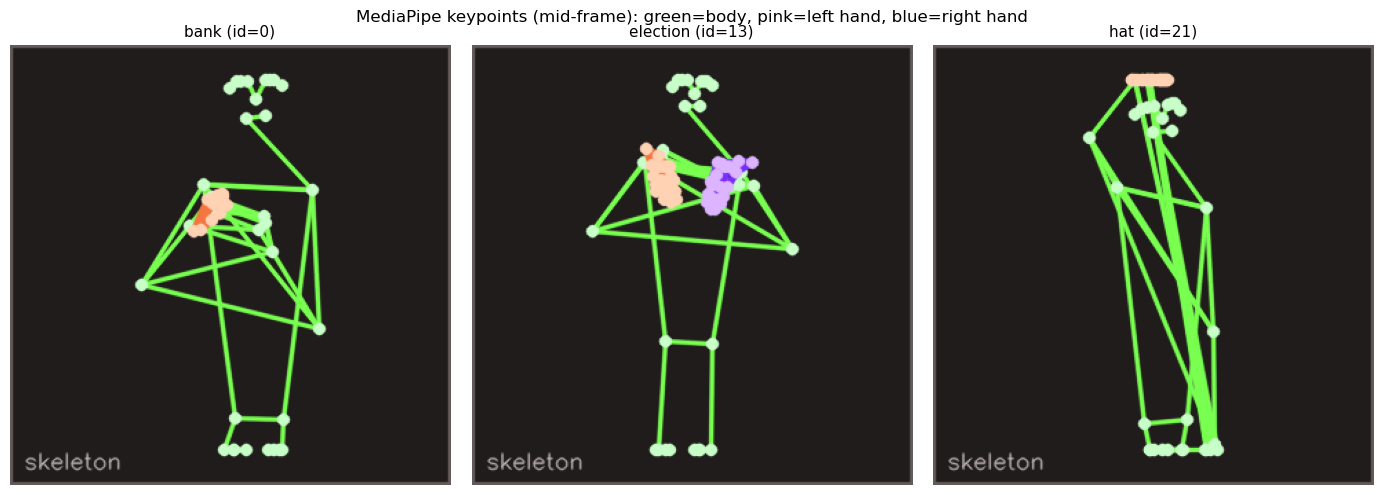

  • bank              T=82 frames
  • election          T=80 frames
  • hat               T=59 frames


In [ ]:
label_map, idx_to_label = C.load_label_map()

samples = train_df.sample(3, random_state=42)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (_, row) in zip(axes, samples.iterrows()):
    stem = Path(row["path"]).stem
    lp = landmarks_dir / row["label"] / f"{stem}.npy"
    bp = body_dir / row["label"] / f"{stem}.npy"
    fp = face_dir / row["label"] / f"{stem}.npy"
    hands, body, face, t = load_streams(lp, bp, fp, MAX_SEQ_LEN, require_body=True)
    mid = t // 2
    panel = render_skeleton_panel(hands[mid], body[mid], face[mid], panel_size=320)
    ax.imshow(panel[:, :, ::-1])  # BGR -> RGB for matplotlib
    ax.set_title(f"{row['label']} (id={int(row['label_id'])})", fontsize=11)
    ax.axis("off")

fig.suptitle("MediaPipe keypoints (mid-frame): green=body, pink=left hand, blue=right hand", fontsize=12)
plt.tight_layout()
plt.show()

for _, row in samples.iterrows():
    stem = Path(row["path"]).stem
    n_frames = len(np.load(landmarks_dir / row["label"] / f"{stem}.npy", mmap_mode="r"))
    print(f"  • {row['label']:16s}  T={n_frames} frames")

## 3. DataLoaders & MSPT model

In [4]:
ds_kw = dict(require_body=True)
train_ds = MSPTDataset(manifests/"train.csv", landmarks_dir, body_dir, face_dir,
                       max_frames=MAX_SEQ_LEN, split="train", training=True, repeat=AUG_REPEAT, **ds_kw)
val_ds = MSPTDataset(manifests/"val.csv", landmarks_dir, body_dir, face_dir,
                     max_frames=MAX_SEQ_LEN, split="val", training=False, **ds_kw)
test_ds = MSPTDataset(manifests/"test.csv", landmarks_dir, body_dir, face_dir,
                      max_frames=MAX_SEQ_LEN, split="test", training=False, **ds_kw)

loader_kw = dict(num_workers=NUM_WORKERS, pin_memory=DEVICE.startswith("cuda"),
                 collate_fn=collate_mspt_batch, persistent_workers=NUM_WORKERS > 0)
train_dl = DataLoader(train_ds, batch_size=MICRO_BS, shuffle=True, drop_last=True, **loader_kw)
val_dl = DataLoader(val_ds, batch_size=MICRO_BS, shuffle=False, **loader_kw)
test_dl = DataLoader(test_ds, batch_size=MICRO_BS, shuffle=False, **loader_kw)

model = MSPT(hand_dim=HAND_DIM, body_dim=BODY_DIM, face_dim=FACE_DIM,
             num_classes=C.NUM_CLASSES, max_len=MAX_SEQ_LEN,
             use_checkpoint=True, sequential_streams=True).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Train samples/epoch: {len(train_ds)} (aug_repeat={AUG_REPEAT})")
print(f"Val: {len(val_ds)}  Test: {len(test_ds)}  |  Parameters: {n_params:,}")

Train samples/epoch: 591 (aug_repeat=1)
Val: 129  Test: 130  |  Parameters: 3,435,570


## 4. Training loop (epoch logs + early stopping)

In [5]:
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
crit = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
scaler = torch.amp.GradScaler("cuda", enabled=DEVICE.startswith("cuda"))
amp_on = DEVICE.startswith("cuda")

history = {"epoch": [], "train_loss": [], "val_acc": [], "lr": []}
best_val, stale = 0.0, 0

if DEVICE.startswith("cuda"):
    torch.cuda.reset_peak_memory_stats()

for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    opt.zero_grad(set_to_none=True)
    for step, batch in enumerate(train_dl):
        with torch.autocast("cuda", enabled=amp_on):
            hand = batch["hand"].to(DEVICE, non_blocking=True)
            body = batch["body"].to(DEVICE, non_blocking=True)
            face = batch["face"].to(DEVICE, non_blocking=True)
            mask = batch["mask"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)
            logits = model(hand, body, face, mask)
            loss = crit(logits, labels) / GRAD_ACCUM
        scaler.scale(loss).backward()
        running += loss.item() * GRAD_ACCUM
        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(train_dl):
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
            opt.zero_grad(set_to_none=True)
        del hand, body, face, mask, labels, logits, loss

    sched.step()
    val_acc, _, _ = evaluate(model, val_dl, DEVICE, use_amp=amp_on)
    train_loss = running / max(1, len(train_dl))
    lr_now = sched.get_last_lr()[0]

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(lr_now)

    if val_acc > best_val:
        best_val = val_acc
        stale = 0
        torch.save({"model": model.state_dict(), "val_acc": val_acc, "epoch": epoch + 1}, DEMO_CKPT)
    else:
        stale += 1

    mem = torch.cuda.max_memory_allocated() / 1e6 if DEVICE.startswith("cuda") else 0
    print(f"epoch {epoch+1:3d}/{EPOCHS}  loss={train_loss:.3f}  val_acc={val_acc:.3f}  best={best_val:.3f}  lr={lr_now:.2e}" + (f"  gpu_mb={mem:.0f}" if mem else ""))
    gc.collect()
    if stale >= PATIENCE:
        print(f"Early stop at epoch {epoch+1}")
        break

hist_df = pd.DataFrame(history)
try:
    from IPython.display import display
except ImportError:
    display = print
display(hist_df)

epoch   1/12  loss=4.034  val_acc=0.039  best=0.039  lr=9.83e-05  gpu_mb=89


epoch   2/12  loss=3.983  val_acc=0.000  best=0.039  lr=9.33e-05  gpu_mb=89


epoch   3/12  loss=3.944  val_acc=0.000  best=0.039  lr=8.54e-05  gpu_mb=89


epoch   4/12  loss=3.918  val_acc=0.031  best=0.039  lr=7.50e-05  gpu_mb=89


epoch   5/12  loss=3.884  val_acc=0.031  best=0.039  lr=6.29e-05  gpu_mb=89
Early stop at epoch 5


,epoch,train_loss,val_acc,lr
0,1,4.034499,0.038760,0.000098
1,2,3.983494,0.000000,0.000093
2,3,3.944211,0.000000,0.000085
3,4,3.918172,0.031008,0.000075
4,5,3.883901,0.031008,0.000063


## 5. Training curves

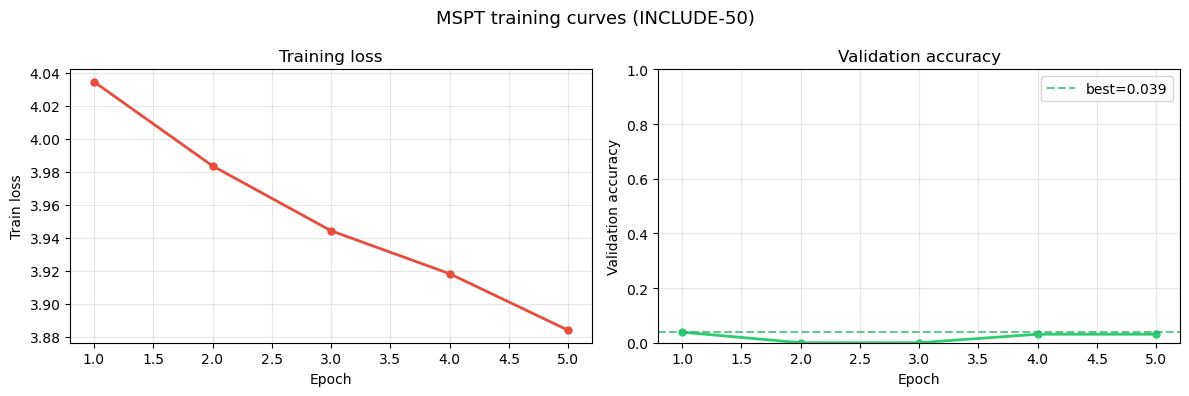

Saved: /home/mathew/signbert_unofficial/notebooks/mspt_demo_training_curves.png


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist_df["epoch"], hist_df["train_loss"], "o-", color="#e74c3c", linewidth=2, markersize=5)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train loss")
ax1.set_title("Training loss")
ax1.grid(True, alpha=0.3)

ax2.plot(hist_df["epoch"], hist_df["val_acc"], "o-", color="#2ecc71", linewidth=2, markersize=5)
ax2.axhline(best_val, color="#27ae60", linestyle="--", alpha=0.7, label=f"best={best_val:.3f}")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation accuracy")
ax2.set_ylim(0, 1)
ax2.set_title("Validation accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("MSPT training curves (INCLUDE-50)", fontsize=13)
plt.tight_layout()
curve_path = NOTEBOOKS / "mspt_demo_training_curves.png"
plt.savefig(curve_path, dpi=120, bbox_inches="tight")
plt.show()
print("Saved:", curve_path)

## 6. Final metrics (best checkpoint)

## 7. Full training run (reference) — curves from log + `mspt_best.pt` metrics

The cell above is a **fast demo** (12 epochs, no aug repeat). The production model was trained longer; below we load its log and checkpoint for mentor-ready results.

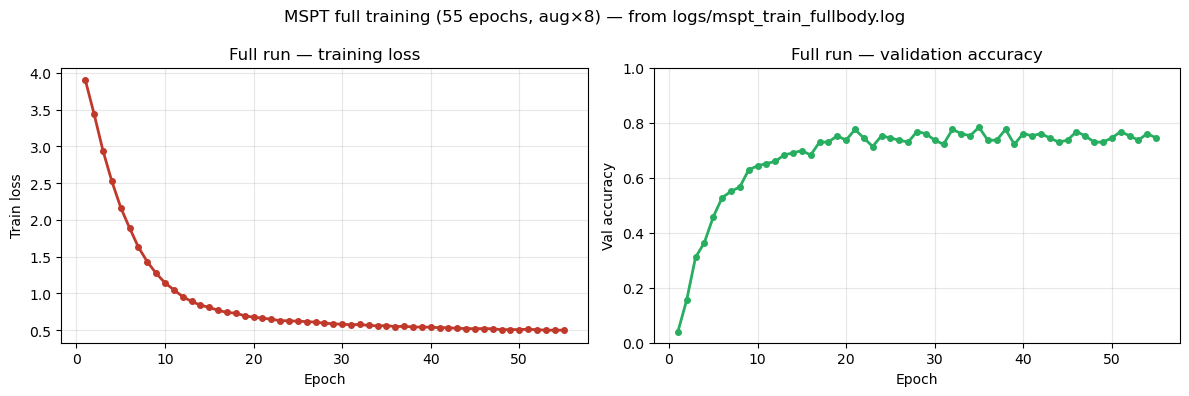

 epoch  train_loss  val_acc
    48       0.506    0.729
    49       0.507    0.729
    50       0.508    0.744
    51       0.512    0.767
    52       0.506    0.752
    53       0.500    0.736
    54       0.499    0.760
    55       0.500    0.744


In [ ]:
import re

log_path = NOTEBOOKS / "logs" / "mspt_train_fullbody.log"
log_text = log_path.read_text() if log_path.exists() else ""

full_hist = {"epoch": [], "train_loss": [], "val_acc": []}
for m in re.finditer(r"epoch (\d+)/\d+ loss=([\d.]+) val_acc=([\d.]+)", log_text):
    full_hist["epoch"].append(int(m.group(1)))
    full_hist["train_loss"].append(float(m.group(2)))
    full_hist["val_acc"].append(float(m.group(3)))

full_df = pd.DataFrame(full_hist)
if len(full_df):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(full_df["epoch"], full_df["train_loss"], "o-", color="#c0392b", lw=2, ms=4)
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Train loss"); ax1.set_title("Full run — training loss"); ax1.grid(alpha=0.3)
    ax2.plot(full_df["epoch"], full_df["val_acc"], "o-", color="#27ae60", lw=2, ms=4)
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Val accuracy"); ax2.set_ylim(0, 1)
    ax2.set_title("Full run — validation accuracy"); ax2.grid(alpha=0.3)
    plt.suptitle("MSPT full training (55 epochs, aug×8) — from logs/mspt_train_fullbody.log", fontsize=12)
    plt.tight_layout()
    plt.savefig(NOTEBOOKS / "mspt_full_training_curves.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(full_df.tail(8).to_string(index=False))
else:
    print("Log not found:", log_path)

In [ ]:
PROD_CKPT = CKPT_DIR / "mspt_best.pt"
prod = torch.load(PROD_CKPT, map_location=DEVICE, weights_only=False)
model.load_state_dict(prod["model"])
print(f"Production checkpoint: epoch={prod.get('epoch')}  val_acc={prod.get('val_acc', 0):.3f}")

_train_eval_ds = MSPTDataset(manifests/"train.csv", landmarks_dir, body_dir, face_dir,
                             max_frames=MAX_SEQ_LEN, split="train", training=False, **ds_kw)
train_eval_dl = DataLoader(_train_eval_ds, batch_size=MICRO_BS, shuffle=False, **loader_kw)

train_acc_p, ytr_t, ytr_p = evaluate(model, train_eval_dl, DEVICE, use_amp=amp_on)
val_acc_p, yv_t, yv_p = evaluate(model, val_dl, DEVICE, use_amp=amp_on)
test_acc_p, yt, yp = evaluate(model, test_dl, DEVICE, use_amp=amp_on)

prod_metrics = pd.DataFrame([
    {"split": "train", "accuracy": train_acc_p, "correct": int((ytr_t == ytr_p).sum()), "total": len(ytr_t)},
    {"split": "val", "accuracy": val_acc_p, "correct": int((yv_t == yv_p).sum()), "total": len(yv_t)},
    {"split": "test", "accuracy": test_acc_p, "correct": int((yt == yp).sum()), "total": len(yt)},
])
prod_metrics["accuracy_pct"] = (prod_metrics["accuracy"] * 100).round(2)
display(prod_metrics)
print(f"\nCheckpoint: {PROD_CKPT}")

Production checkpoint: epoch=35  val_acc=0.783


,split,accuracy,correct,total,accuracy_pct
0,train,0.956007,565,591,95.60
1,val,0.782946,101,129,78.29
2,test,0.769231,100,130,76.92



Checkpoint: /home/mathew/signbert_unofficial/notebooks/checkpoints/mspt_best.pt


In [ ]:
ckpt = torch.load(DEMO_CKPT, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model"])
print(f"Loaded best checkpoint epoch={ckpt['epoch']}  val_acc={ckpt['val_acc']:.3f}")

train_eval_ds = MSPTDataset(manifests/"train.csv", landmarks_dir, body_dir, face_dir,
                            max_frames=MAX_SEQ_LEN, split="train", training=False, **ds_kw)
train_eval_dl = DataLoader(train_eval_ds, batch_size=MICRO_BS, shuffle=False, **loader_kw)

train_acc, _, _ = evaluate(model, train_eval_dl, DEVICE, use_amp=amp_on)
val_acc, yv_t, yv_p = evaluate(model, val_dl, DEVICE, use_amp=amp_on)
test_acc, yt, yp = evaluate(model, test_dl, DEVICE, use_amp=amp_on)

metrics = pd.DataFrame([
    {"split": "train", "accuracy": train_acc, "correct": int((yv_t==yv_p).sum()) if False else "—", "total": len(train_eval_ds)},
    {"split": "val", "accuracy": val_acc, "correct": int((yv_t==yv_p).sum()), "total": len(yv_t)},
    {"split": "test", "accuracy": test_acc, "correct": int((yt==yp).sum()), "total": len(yt)},
])
# fix train correct count
_, ytr_t, ytr_p = evaluate(model, train_eval_dl, DEVICE, use_amp=amp_on)
metrics.loc[metrics["split"] == "train", "correct"] = int((ytr_t == ytr_p).sum())
metrics["accuracy_pct"] = (metrics["accuracy"] * 100).round(2)

display(metrics)
print("\nReference full run (50 epochs, aug×8): test ≈ 76.9% — see logs/mspt_train_fullbody.log")

per_class = []
for c in range(C.NUM_CLASSES):
    m = yt == c
    if m.sum():
        per_class.append({"label_id": c, "gloss": idx_to_label[c], "test_acc": float((yp[m] == c).mean()), "n": int(m.sum())})
worst = pd.DataFrame(per_class).sort_values("test_acc").head(5)
print("\nHardest 5 classes on test:")
display(worst)

Loaded best checkpoint epoch=1  val_acc=0.039


,split,accuracy,correct,total,accuracy_pct
0,train,0.021997,13,591,2.20
1,val,0.038760,5,129,3.88
2,test,0.000000,0,130,0.00



Reference full run (50 epochs, aug×8): test ≈ 76.9% — see logs/mspt_train_fullbody.log

Hardest 5 classes on test:


,label_id,gloss,test_acc,n
0,0,bank,0.0,3
1,1,big_large,0.0,5
2,2,bird,0.0,5
3,3,black,0.0,2
4,4,boy,0.0,2
